<a id="setup"></a>
## Step 1: Setup

In [4]:
from sympy import *
from IPython.display import display

init_printing(use_latex="mathjax")

# SYMBOLIC DEFINITIONS

phi, theta, delta = symbols('phi theta delta', real=True)

phi_EOM1 = symbols(r'\phi_{eom1}', real=True)
phi_EOM2 = symbols(r'\phi_{eom2}', real=True)
phi_EOM3 = symbols(r'\phi_{eom3}', real=True)
phi_PZT1 = symbols(r'\phi_{pzt}', real=True)
phi1 = symbols(r'\phi_{1}', real=True)
phi2 = symbols(r'\phi_{2}', real=True)


Ex, Ey = symbols('E_x E_y', complex=True)

ax, ay = symbols('a_x a_y', real = True)

# Some math definitions:
 
t = 1/sqrt(2)
r = I/sqrt(2)

# INPUT FIELD

# Here Ein is chosen with equal amplitudes where delta = 0 produces a pi/4 linearly polarized beam

Ein = Matrix([
    [ax * exp(I * delta)],
    [ay]
])

display(Ein)

# OPTICAL ELEMENT JONES MATRICES

# Each optical element in the system is defined below.

def Mirror():

    return eye(2)
    

def PBS_T():

    return Matrix([
        [1,0],
        [0,0]
    ])


def PBS_R():

    return Matrix([
        [0,0],
        [0,1]
    ])


def BS(EA, EB):

    t = 1/sqrt(2)
    r = I/sqrt(2)

    EC = simplify(t*EA + r*EB)
    ED = simplify(r*EA + t*EB)

    return EC, ED


def EOM1(phi_EOM1):

    return Matrix([
        [exp(I*phi_EOM1),0],
        [0,1]
    ])

def EOM2(phi_EOM2):

    return Matrix([
        [exp(I*phi_EOM2),0],
        [0,1]
    ])

def EOM3(phi3_EOM3):

    return Matrix([
        [1,0],
        [0,exp(I*phi_EOM3)]
    ])

def PZT(phi_PZT1):

    return Matrix([
        [exp(I*phi_PZT1), 0],
        [0, exp(I*phi_PZT1)]
    ])

# PROPAGATION FUNCTION

def propagate(E, *elements):

    for M in elements:
        E = M * E

    return E

# BEAM SPLITTER COMBINATION FUNCTION

def combine(EA, EB):
    EC = r*EA + t*EB
    ED = r*EB + t*EA
    return EC, ED

# PROPAGATE Ein THROUGH INTERFEROMETER

def interferometer(Ein, phi1, phi2):

    armA = Matrix([
        [ax],
        [0]
    ])
    
    armB = Matrix([
        [0],
        [0]
    ])

    armC, armD = combine(armA, armB)

    armC = propagate(
        armC,
        Mirror(),
        PZT(phi2)
    )

    armD = propagate(
        armD,
        Mirror()
    )

    armE, armF = combine(armC, armD)
    
    return {
    "armA": armA,
    "armB": armB,
    "armC": armC,
    "armD": armD,
    "armE": armE,
    "armF": armF,
}

# RUN THE INTERFEROMETER FOR EACH ARM

arms = interferometer(Ein, phi1, phi2)

display(simplify(arms["armE"]))
print(simplify(arms["armE"]))
print("")
display(simplify(arms["armF"]))
print(simplify(arms["armF"]))

fields = interferometer(Ein, phi1, phi2)

IE = simplify((fields["armE"].H * fields["armE"])[0])
IF = simplify((fields["armF"].H * fields["armF"])[0])

display(IF)
display(IE)

print(IF)
print(IE)

IE_equal = simplify(IE.subs({ax:1, ay:1}))
IF_equal = simplify(IF.subs({ax:1, ay:1}))

print(IE_equal)
print(IF_equal)

⎡    ⅈ⋅δ⎤
⎢aₓ⋅ℯ   ⎥
⎢       ⎥
⎣  a_y  ⎦

⎡   ⎛     ⅈ⋅\phi_{2}⎞⎤
⎢aₓ⋅⎝1 - ℯ          ⎠⎥
⎢────────────────────⎥
⎢         2          ⎥
⎢                    ⎥
⎣         0          ⎦

Matrix([[a_x*(1 - exp(I*\phi_{2}))/2], [0]])



⎡     ⎛ ⅈ⋅\phi_{2}    ⎞⎤
⎢ⅈ⋅aₓ⋅⎝ℯ           + 1⎠⎥
⎢──────────────────────⎥
⎢          2           ⎥
⎢                      ⎥
⎣          0           ⎦

Matrix([[I*a_x*(exp(I*\phi_{2}) + 1)/2], [0]])


  2    2⎛\phi_{2}⎞
aₓ ⋅cos ⎜────────⎟
        ⎝   2    ⎠

  2    2⎛\phi_{2}⎞
aₓ ⋅sin ⎜────────⎟
        ⎝   2    ⎠

a_x**2*cos(\phi_{2}/2)**2
a_x**2*sin(\phi_{2}/2)**2
sin(\phi_{2}/2)**2
cos(\phi_{2}/2)**2


In [ ]:
from sympy import *
from IPython.display import display

init_printing(use_latex="mathjax")

# SYMBOLIC DEFINITIONS

phi, theta, delta = symbols('phi theta delta', real=True)

phi_EOM1 = symbols(r'\phi_{eom1}', real=True)
phi_EOM2 = symbols(r'\phi_{eom2}', real=True)
phi_EOM3 = symbols(r'\phi_{eom3}', real=True)
phi_PZT1 = symbols(r'\phi_{pzt}', real=True)
phi1 = symbols(r'\phi_{1}', real=True)
phi2 = symbols(r'\phi_{2}', real=True)


Ex, Ey = symbols('E_x E_y', complex=True)

ax, ay = symbols('a_x a_y', real = True)

# Some math definitions:

RA = 386/(386+333)   # 0.5369
TA = 333/(386+333)   # 0.4631

RB = 360/(360+375)   # 0.4898
TB = 375/(360+375)   # 0.5102
 
rA = I*sqrt(RA)
tA = sqrt(TA)

rB = I*sqrt(RB)
tB = sqrt(TB)

R_BS = Matrix([
    [rA, 0],
    [0, rB]
])

T_BS = Matrix([
    [tA, 0],
    [0, tB]
])

# INPUT FIELD

# Here Ein is chosen with equal amplitudes where delta = 0 produces a pi/4 linearly polarized beam

Ein = Matrix([
    [ax * exp(I * delta)],
    [ay]
])

display(Ein)

# OPTICAL ELEMENT JONES MATRICES

# Each optical element in the system is defined below.

def Mirror():

    return eye(2)
    

def PBS_T():

    return Matrix([
        [1,0],
        [0,0]
    ])


def PBS_R():

    return Matrix([
        [0,0],
        [0,1]
    ])


def BS(EA, EB):

    t = 1/sqrt(2)
    r = I/sqrt(2)

    EC = simplify(t*EA + r*EB)
    ED = simplify(r*EA + t*EB)

    return EC, ED


def EOM1(phi_EOM1):

    return Matrix([
        [exp(I*phi_EOM1),0],
        [0,1]
    ])

def EOM2(phi_EOM2):

    return Matrix([
        [exp(I*phi_EOM2),0],
        [0,1]
    ])

def EOM3(phi3_EOM3):

    return Matrix([
        [1,0],
        [0,exp(I*phi_EOM3)]
    ])

eta_pzt = Rational(675,730)      # symbolic
amp_pzt = sqrt(eta_pzt)

def PZT(phi):

    return Matrix([
        [amp_pzt*exp(I*phi),0],
        [0,amp_pzt*exp(I*phi)]
    ])
# PROPAGATION FUNCTION

def propagate(E, *elements):

    for M in elements:
        E = M * E

    return E

# BEAM SPLITTER COMBINATION FUNCTION

def combine(EA, EB):

    EC = simplify(R_BS*EA + T_BS*EB)
    ED = simplify(T_BS*EA + R_BS*EB)

    return EC, ED

# PROPAGATE Ein THROUGH INTERFEROMETER

def interferometer(Ein, phi1, phi2):

    armA = propagate(
        Ein,
        PBS_T(),
        Mirror()
    )

    armB = propagate(
        Ein,
        PBS_R(),
        Mirror(),
        PZT(phi1)
    )

    armC, armD = combine(armA, armB)

    armC = propagate(
        armC,
        Mirror(),
        PZT(phi2)
    )

    armD = propagate(
        armD,
        Mirror()
    )

    armE, armF = combine(armC, armD)
    
    return {
    "armA": armA,
    "armB": armB,
    "armC": armC,
    "armD": armD,
    "armE": armE,
    "armF": armF,
}

# RUN THE INTERFEROMETER FOR EACH ARM

arms = interferometer(Ein, phi1, phi2)

display(simplify(arms["armE"]))
print(simplify(arms["armE"]))
print("")
display(simplify(arms["armF"]))
print(simplify(arms["armF"]))

fields = interferometer(Ein, phi1, phi2)

IE = simplify((fields["armE"].H * fields["armE"])[0])
IF = simplify((fields["armF"].H * fields["armF"])[0])


display(IF)
display(IE)

print(IF)
print(IE)

IE_equal = simplify(IE.subs({ax:1, ay:1}))
IF_equal = simplify(IF.subs({ax:1, ay:1}))

print(IE_equal)
print(IF_equal)


In [ ]:
# CALCULATION PREREQUISITES

def components(field):

    Ex = field[0]
    Ey = field[1]

    return Ex, Ey


def intensity(field):

    Ex, Ey = components(field)

    return simplify(
        conjugate(Ex)*Ex +
        conjugate(Ey)*Ey
    )

field = arms["armE"]

Ex, Ey = components(field)

Itot = intensity(field)

display(simplify(Itot))

# DEFINE STOKES PARAMETERS

def stokes(field):

    Ex, Ey = components(field)

    S0 = simplify(conjugate(Ex)*Ex + conjugate(Ey)*Ey)

    S1 = simplify(conjugate(Ex)*Ex - conjugate(Ey)*Ey)

    S2 = simplify(2*re(Ex*conjugate(Ey)))

    S3 = simplify(2*im(Ex*conjugate(Ey)))

    return Matrix([
        [S0],
        [S1],
        [S2],
        [S3]
    ])

display(simplify(stokes(field)))

# EVALUATE STOKES VECTOR

field = arms["armE"]

S = stokes(field)

# Choose experimental parameters

S_eval = simplify(
    S.subs({
        ax: 1/sqrt(2), # Normalized amplitude
        ay: 1/sqrt(2),
        delta: 0,
    })
)

display(S_eval)

print(S_eval)

# Confirm S1 = 0 Condition (typically pi or pi/2 depending on architecture)

S_pi = simplify(
    S_eval.subs(phi_PZT1, pi / 2)
)

display(S_pi)

S_zero = simplify(
    S_eval.subs(phi_PZT1, 0)
)

display(S_zero)

### Parameterization

In [43]:
# GENERALIZED POINCARE SPHERE COORDINATE EXTRACTION

from sympy import atan2, acos, simplify, trigsimp


def poincare_coordinates(S):
    """
    Convert symbolic Stokes vector into spherical coordinates.

    Uses S1 as the polar axis:
    
        S1 = cos(v)
        S2 = sin(v) cos(u)
        S3 = sin(v) sin(u)

    Returns:
        normalized Stokes vector
        u (azimuth)
        v (polar angle)
    """

    # Extract components
    S0 = simplify(S[0])
    S1 = simplify(S[1])
    S2 = simplify(S[2])
    S3 = simplify(S[3])

    # Normalize
    S1n = simplify(S1/S0)
    S2n = simplify(S2/S0)
    S3n = simplify(S3/S0)

    S_norm = Matrix([
        [S1n],
        [S2n],
        [S3n]
    ])

    # Spherical coordinates
    #
    # S1 = cos(v)
    #
    v = simplify(acos(S1n))

    #
    # S2 = sin(v)cos(u)
    # S3 = sin(v)sin(u)
    #
    u = simplify(atan2(S3n, S2n))

    return S_norm, simplify(u), simplify(v)



# APPLY TO YOUR FIELD

field = arms["armE"]

S = stokes(field)


# Experimental substitutions

S_eval = simplify(
    S.subs({
        ax: 1/sqrt(2),
        ay: 1/sqrt(2),
        delta: 0,
    })
)


print("Normalized Stokes:")
S_norm, u_expr, v_expr = poincare_coordinates(S_eval)

display(S_norm)

print("u:")
display(trigsimp(u_expr))

print("v:")
display(trigsimp(v_expr))

print(S_norm)
print("u =", trigsimp(u_expr))
print("v = ", trigsimp(v_expr))

Normalized Stokes:


⎡               cos(\phi_{eom}) + 1                ⎤
⎢               ───────────────────                ⎥
⎢               cos(\phi_{eom}) - 3                ⎥
⎢                                                  ⎥
⎢2⋅(sin(\phi_{pzt}) + sin(\phi_{eom} - \phi_{pzt}))⎥
⎢──────────────────────────────────────────────────⎥
⎢               cos(\phi_{eom}) - 3                ⎥
⎢                                                  ⎥
⎢2⋅(cos(\phi_{pzt}) - cos(\phi_{eom} - \phi_{pzt}))⎥
⎢──────────────────────────────────────────────────⎥
⎣               cos(\phi_{eom}) - 3                ⎦

u:


     ⎛2⋅(cos(\phi_{pzt}) - cos(\phi_{eom} - \phi_{pzt}))  2⋅(sin(\phi_{pzt}) + ↪
atan2⎜──────────────────────────────────────────────────, ──────────────────── ↪
     ⎝               cos(\phi_{eom}) - 3                                 cos(\ ↪

↪  sin(\phi_{eom} - \phi_{pzt}))⎞
↪ ──────────────────────────────⎟
↪ phi_{eom}) - 3                ⎠

v:


    ⎛cos(\phi_{eom}) + 1⎞
acos⎜───────────────────⎟
    ⎝cos(\phi_{eom}) - 3⎠

Matrix([[(cos(\phi_{eom}) + 1)/(cos(\phi_{eom}) - 3)], [2*(sin(\phi_{pzt}) + sin(\phi_{eom} - \phi_{pzt}))/(cos(\phi_{eom}) - 3)], [2*(cos(\phi_{pzt}) - cos(\phi_{eom} - \phi_{pzt}))/(cos(\phi_{eom}) - 3)]])
u = atan2(2*(cos(\phi_{pzt}) - cos(\phi_{eom} - \phi_{pzt}))/(cos(\phi_{eom}) - 3), 2*(sin(\phi_{pzt}) + sin(\phi_{eom} - \phi_{pzt}))/(cos(\phi_{eom}) - 3))
v =  acos((cos(\phi_{eom}) + 1)/(cos(\phi_{eom}) - 3))


### Numerical Evaluation

In [44]:
# NUMERICAL FUNCTIONS

from sympy import lambdify
import numpy as np
import matplotlib.pyplot as plt

S_func = lambdify(
    (phi_EOM1, phi_PZT1),
    S_eval,
    modules="numpy"
)

In [45]:
# EVALUATE STOKES NUMERICALLY

def evaluate_stokes(phi1, phi2):

    phi1 = np.asarray(phi1)
    phi2 = np.asarray(phi2)

    phi1, phi2 = np.broadcast_arrays(phi1, phi2)

    S = S_func(phi1, phi2)

    S = np.asarray(S)

    # FORCE consistent shape: (4, N)
    if S.ndim == 2:
        return S
    elif S.ndim == 3:
        return np.squeeze(S)
    else:
        raise ValueError(f"Unexpected shape: {S.shape}")

In [46]:
def normalize_stokes(S):

    S = np.asarray(S)

    S0 = S[0]
    S1 = S[1]
    S2 = S[2]
    S3 = S[3]

    denom = S0

    return np.array([
        S1 / denom,
        S2 / denom,
        S3 / denom
    ])

## Plotting

### 2D S1 = 0

<IPython.core.display.Math object>

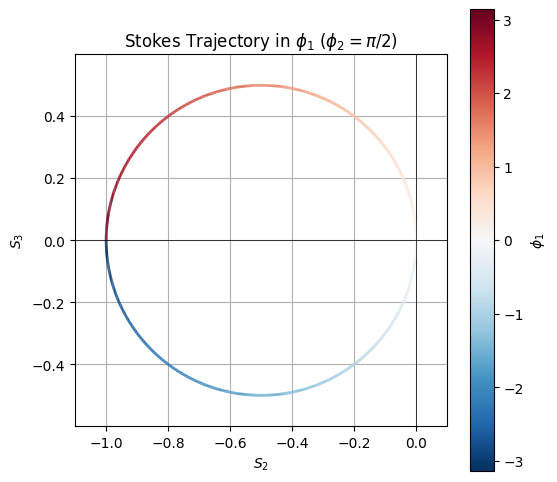

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from IPython.display import display, Math


phi2_fixed = np.pi / 2

display(Math(r"\phi_1 \mapsto (S_2(\phi_1,\phi_2=\pi/2),\; S_3(\phi_1,\phi_2=\pi/2))"))

phi1_vals = np.linspace(-np.pi, np.pi, 1000)

S2_vals = []
S3_vals = []

for phi1 in phi1_vals:

    # use fixed φ2 = π/2
    S = S_func(phi1, phi2_fixed)
    S = np.squeeze(S)

    S2_vals.append(S[2])
    S3_vals.append(S[3])

S2_vals = np.array(S2_vals)
S3_vals = np.array(S3_vals)


points = np.array([S2_vals, S3_vals]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# color by phi1
norm = plt.Normalize(phi1_vals.min(), phi1_vals.max())
lc = LineCollection(segments, cmap='RdBu_r', norm=norm)
lc.set_array(phi1_vals)
lc.set_linewidth(2)


fig, ax = plt.subplots(figsize=(6, 6))
ax.add_collection(lc)

x_margin = 0.1 * (S2_vals.max() - S2_vals.min())
y_margin = 0.1 * (S3_vals.max() - S3_vals.min())

ax.set_xlim(S2_vals.min() - x_margin, S2_vals.max() + x_margin)
ax.set_ylim(S3_vals.min() - y_margin, S3_vals.max() + y_margin)

ax.set_xlabel(r"$S_2$")
ax.set_ylabel(r"$S_3$")
ax.set_title(r"Stokes Trajectory in $\phi_1$ ($\phi_2 = \pi/2$)")

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

ax.set_aspect('equal')
ax.grid(True)

cbar = fig.colorbar(lc, ax=ax)
cbar.set_label(r"$\phi_1$")

plt.show()

### 3D

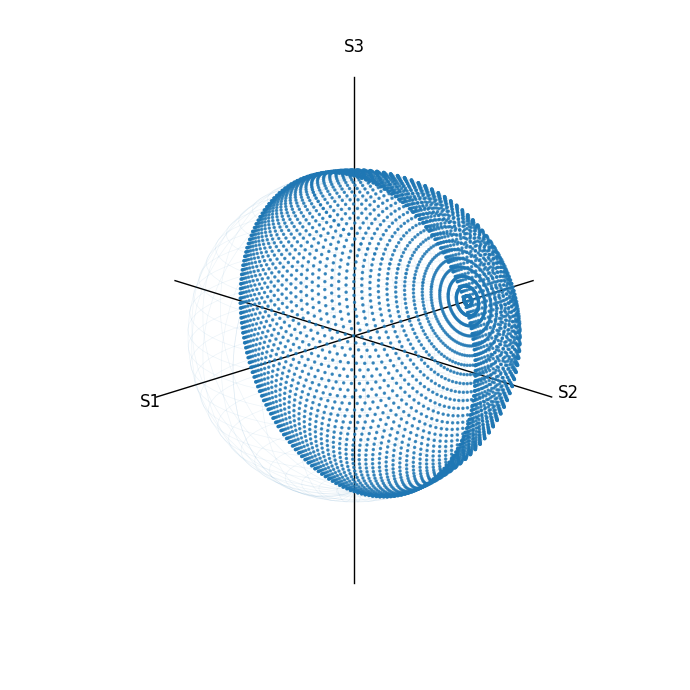

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


S1_grid, S2_grid, S3_grid = [], [], []

phi1_vals = np.linspace(-np.pi, np.pi, 100)
phi2_vals = np.linspace(-np.pi, np.pi, 100)

for p1 in phi1_vals:
    for p2 in phi2_vals:

        S = np.squeeze(S_func(p1, p2))
        S0, S1, S2, S3 = S

        if np.abs(S0) < 1e-12:
            continue

        vec = np.array([S1, S2, S3]) / S0
        vec = np.real(vec)

        S1_grid.append(vec[0])
        S2_grid.append(vec[1])
        S3_grid.append(vec[2])

Sx = np.array(S1_grid)
Sy = np.array(S2_grid)
Sz = np.array(S3_grid)


fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# REMOVE ALL BOX / PANES
ax.set_axis_off()


ax.scatter(Sx, Sy, Sz, s=2, alpha=0.5)


u = np.linspace(0, 2*np.pi, 60)
v = np.linspace(0, np.pi, 30)

xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

ax.plot_wireframe(xs, ys, zs, alpha=0.08, linewidth=0.5)

axis_len = 1.6

# S1 axis
ax.plot([-axis_len, axis_len], [0, 0], [0, 0], color='black', linewidth=1)
ax.text(axis_len * 1.08, 0, 0, "S1", fontsize=12, ha='left', va='center')

# S2 axis
ax.plot([0, 0], [-axis_len, axis_len], [0, 0], color='black', linewidth=1)
ax.text(0, axis_len * 1.08, 0, "S2", fontsize=12, ha='center', va='bottom')

# S3 axis
ax.plot([0, 0], [0, 0], [-axis_len, axis_len], color='black', linewidth=1)
ax.text(0, 0, axis_len * 1.08, "S3", fontsize=12, ha='center', va='bottom')


ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_zlim(-1.2, 1.2)
ax.set_box_aspect([1, 1, 1])

# no labels, no ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.view_init(elev=18, azim=45)

plt.tight_layout()
plt.show()